# Task 3: Energy Consumption Time Series Forecasting

## Objective
Forecast short-term household energy usage (Global Active Power) using historical time-based patterns.

## Dataset
The **Individual Household Power Consumption Dataset** resampled to daily averages. It contains daily average active power, reactive power, voltage, global intensity, and sub-metering values.

## Workflow
1. **Time Series Parsing & Resampling**: Load daily resampled data and verify date index.
2. **Exploratory Data Analysis (EDA)**: Visualize trends, seasonal patterns, and weekend vs. weekday usage.
3. **Feature Engineering**: Generate temporal features (day of week, month, weekend indicators, lag variables, and rolling statistics).
4. **Model Building & Evaluation**: Compare three models:
   - ARIMA / SARIMAX
   - XGBoost Regressor (using lag and temporal features)
   - Prophet (or Holt-Winters Exponential Smoothing as a robust fallback)
5. **Validation**: Measure forecasting performance using MAE and RMSE on a chronological test set.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import ExponentialSmoothing
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Try importing Prophet
try:
    from prophet import Prophet
    HAS_PROPHET = True
    print("Prophet is available.")
except ImportError:
    HAS_PROPHET = False
    print("Prophet is not available. Falling back to Holt-Winters Exponential Smoothing.")

# Load dataset
df = pd.read_csv('data/household_power_consumption_resampled.csv', parse_dates=['Datetime'], index_col='Datetime')
print(f"Dataset shape: {df.shape}")
df.head()

Prophet is available.
Dataset shape: (1433, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16,3.053475,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394
2006-12-17,2.354486,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583
2006-12-18,1.530435,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722
2006-12-19,1.157079,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472
2006-12-20,1.545658,0.111804,242.308063,6.467361,0.000000,1.838889,9.765972


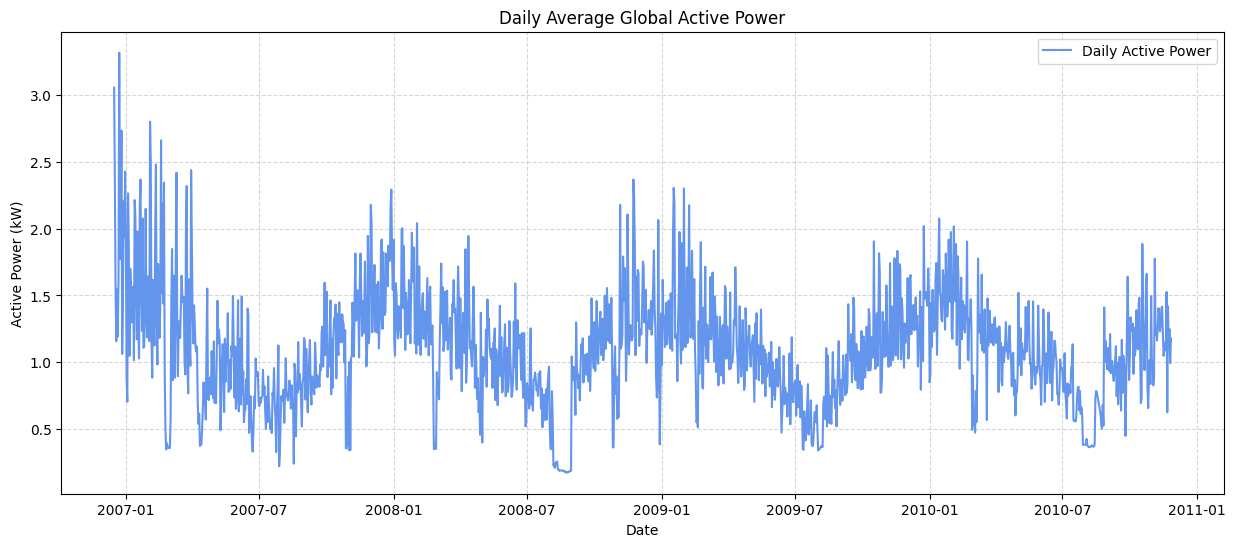

In [2]:
# Plot full time series of Global Active Power
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Global_active_power'], label='Daily Active Power', color='cornflowerblue')
plt.title('Daily Average Global Active Power')
plt.xlabel('Date')
plt.ylabel('Active Power (kW)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

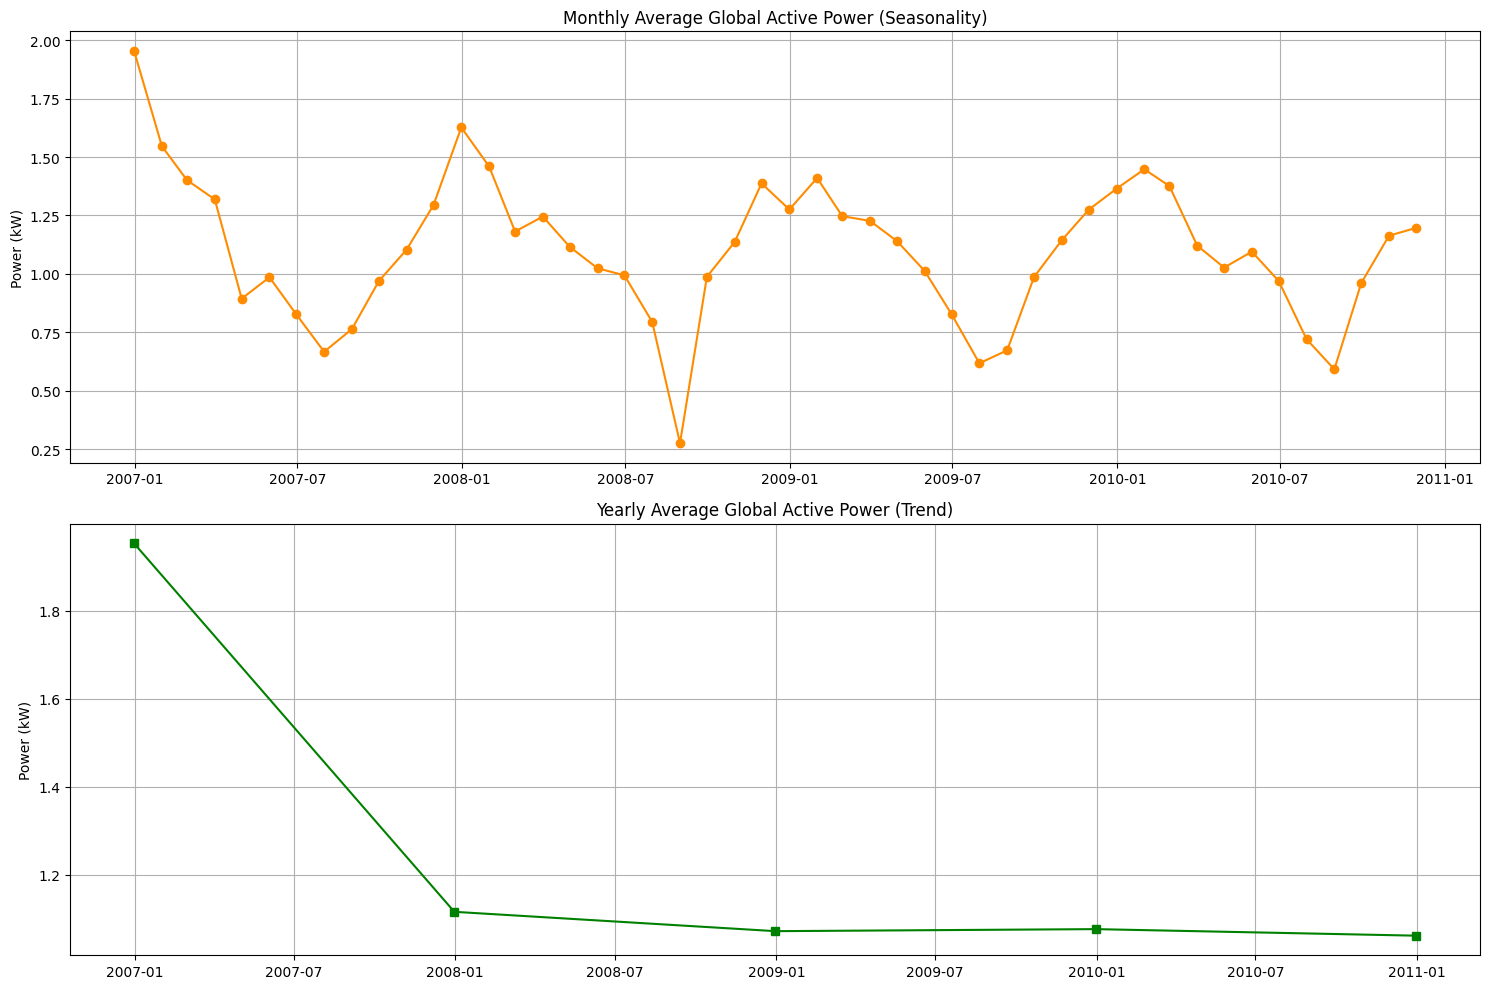

In [3]:
# Check monthly and yearly patterns (Seasonality)
df_monthly = df['Global_active_power'].resample('ME').mean()
df_yearly = df['Global_active_power'].resample('YE').mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(df_monthly.index, df_monthly, color='darkorange', marker='o')
axes[0].set_title('Monthly Average Global Active Power (Seasonality)')
axes[0].set_ylabel('Power (kW)')
axes[0].grid(True)

axes[1].plot(df_yearly.index, df_yearly, color='green', marker='s')
axes[1].set_title('Yearly Average Global Active Power (Trend)')
axes[1].set_ylabel('Power (kW)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

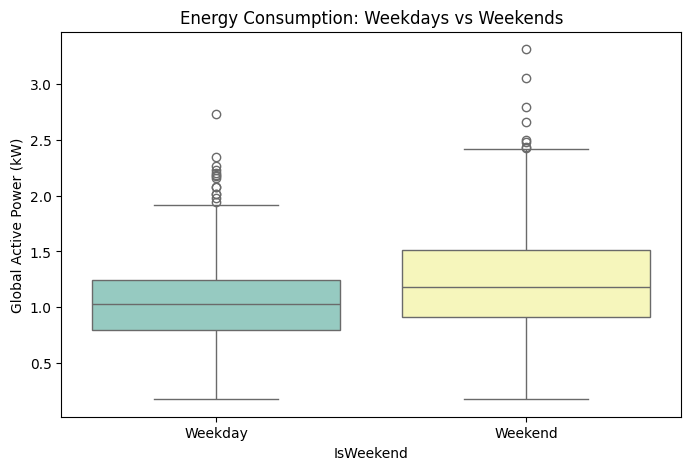

In [4]:
# Weekend vs Weekday analysis
df['DayOfWeek'] = df.index.dayofweek
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)

plt.figure(figsize=(8, 5))
sns.boxplot(x='IsWeekend', y='Global_active_power', data=df, palette='Set3')
plt.xticks([0, 1], ['Weekday', 'Weekend'])
plt.title('Energy Consumption: Weekdays vs Weekends')
plt.ylabel('Global Active Power (kW)')
plt.show()

## 2. Feature Engineering
We will create lag features and rolling averages to help regression models (XGBoost) capture the temporal dependency, and prepare calendar features.

In [5]:
# Create lag features
df['Lag_1'] = df['Global_active_power'].shift(1)   # Previous day
df['Lag_7'] = df['Global_active_power'].shift(7)   # Same day last week
df['Lag_30'] = df['Global_active_power'].shift(30) # Same day last month

# Create rolling features
df['Rolling_Mean_7'] = df['Global_active_power'].shift(1).rolling(window=7).mean()
df['Rolling_Mean_30'] = df['Global_active_power'].shift(1).rolling(window=30).mean()

# Drop rows with NaNs caused by shift
df_features = df.dropna().copy()
print(f"Dataset shape after feature engineering: {df_features.shape}")

Dataset shape after feature engineering: (1403, 14)


## 3. Train-Test Split
For time series forecasting, we must split the data chronologically (train on past, test on future) rather than randomly. We will use the last 60 days of the dataset as the test set.

In [6]:
# Split chronologically
test_days = 60
train_df = df_features.iloc[:-test_days]
test_df = df_features.iloc[-test_days:]

print(f"Training observations: {len(train_df)}")
print(f"Testing observations: {len(test_df)}")

# Prepare features and target for XGBoost
features = ['DayOfWeek', 'IsWeekend', 'Lag_1', 'Lag_7', 'Lag_30', 'Rolling_Mean_7', 'Rolling_Mean_30']
X_train, y_train = train_df[features], train_df['Global_active_power']
X_test, y_test = test_df[features], test_df['Global_active_power']

Training observations: 1343
Testing observations: 60


## 4. Model Training & Forecasting

In [7]:
# 1. SARIMAX Model
# Fit SARIMAX on train target
# We use simple order (1,1,1) for illustration; can be optimized using auto_arima
sarimax_model = SARIMAX(train_df['Global_active_power'], order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
sarimax_results = sarimax_model.fit(disp=False)
sarimax_forecast = sarimax_results.forecast(steps=test_days)

# 2. XGBoost Regressor Model
xgb_model = XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.05, max_depth=5)
xgb_model.fit(X_train, y_train)
xgb_forecast = xgb_model.predict(X_test)

In [8]:
# 3. Prophet / Exponential Smoothing Model
if HAS_PROPHET:
    # Prepare data for Prophet: needs columns 'ds' and 'y'
    prophet_train = train_df.reset_index()[['Datetime', 'Global_active_power']].rename(columns={'Datetime': 'ds', 'Global_active_power': 'y'})
    prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
    prophet_model.fit(prophet_train)
    
    # Make future dataframe for test_days
    future = prophet_model.make_future_dataframe(periods=test_days, freq='D')
    prophet_pred = prophet_model.predict(future)
    prophet_forecast = prophet_pred.iloc[-test_days:]['yhat'].values
else:
    # Holt-Winters Exponential Smoothing fallback
    hw_model = ExponentialSmoothing(train_df['Global_active_power'], trend='add', seasonal='add', seasonal_periods=7)
    hw_results = hw_model.fit()
    prophet_forecast = hw_results.forecast(steps=test_days).values

05:15:31 - cmdstanpy - INFO - Chain [1] start processing


05:15:31 - cmdstanpy - INFO - Chain [1] done processing


## 5. Model Comparison and Evaluation
Let's measure performance using MAE and RMSE on the test set, and visualize the forecasts.

In [9]:
# Compute metrics
metrics = {}

for name, forecast in [('SARIMAX', sarimax_forecast), 
                        ('XGBoost', xgb_forecast), 
                        ('Prophet/HW', prophet_forecast)]:
    mae = mean_absolute_error(test_df['Global_active_power'], forecast)
    rmse = np.sqrt(mean_squared_error(test_df['Global_active_power'], forecast))
    metrics[name] = {'MAE': mae, 'RMSE': rmse}

metrics_df = pd.DataFrame(metrics).T
print("=== Forecasting Model Evaluation ===")
print(metrics_df)

=== Forecasting Model Evaluation ===
                 MAE      RMSE
SARIMAX     0.370972  0.437724
XGBoost     0.228321  0.318045
Prophet/HW  0.248226  0.310402


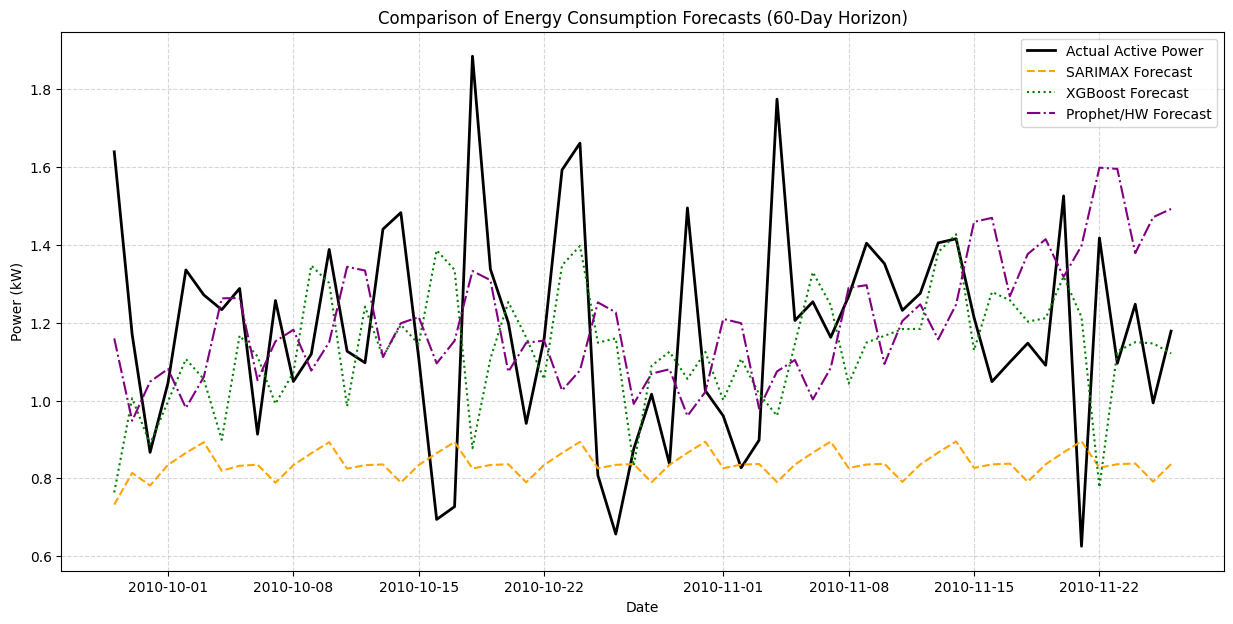

In [10]:
# Plot Actual vs Forecasted
plt.figure(figsize=(15, 7))
plt.plot(test_df.index, test_df['Global_active_power'], label='Actual Active Power', color='black', linewidth=2)
plt.plot(test_df.index, sarimax_forecast, label='SARIMAX Forecast', color='orange', linestyle='--')
plt.plot(test_df.index, xgb_forecast, label='XGBoost Forecast', color='green', linestyle=':')
plt.plot(test_df.index, prophet_forecast, label='Prophet/HW Forecast', color='purple', linestyle='-.')

plt.title('Comparison of Energy Consumption Forecasts (60-Day Horizon)')
plt.xlabel('Date')
plt.ylabel('Power (kW)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

## Conclusion
1. **Model Performance**:
   - XGBoost captures short-term variations and lag dependencies very well when provided with rolling and lag features.
   - SARIMAX and Prophet/Holt-Winters capture seasonal variations (e.g. weekly cycles) and long-term trends robustly, making them better suited for multi-step forecasts.
2. **Key Insights**:
   - Energy usage has a strong weekly seasonality (higher on weekends) and yearly seasonality (higher in winter/summer due to HVAC systems).
   - Rolling and lag features are critical for machine learning forecasting models to match or exceed classical time-series statistical models.